# Statistical inference

> **Chapter resources**
>
> <a href="../files/slides/06_statistical_inference.pdf"
> class="btn btn-sm btn-primary">Slides (PDF)</a> <a
> href="https://colab.research.google.com/github/antoninofurnari/fad-2627/blob/main/notes/06_statistical_inference.ipynb"
> class="btn btn-sm btn-outline-primary">Open in Colab</a>
> <a href="../files/chapters/06_statistical_inference.pdf"
> class="btn btn-sm btn-outline-primary btn-chapter-pdf">Download PDF</a>
> <a href="../quiz.html?bank=06"
> class="btn btn-sm btn-outline-primary">Practice quiz</a>

So far, we have seen methods for describing a sample of data
(descriptive statistics) and we have reasoned on abstract concepts using
basic probability theory concepts. In practice, we are often interested
in the properties of a **population**, rather than a sample or some
abstract quantities. Examples are: \* What is the percentage of votes
each candidate will get at an election? \* What is the proportion of
defective goods in a manufacturing process? \* Is there a relationship
between smoking and developing a given disease in the world population?

One approach to answer these questions would be to collect the whole
population, but this is often unfeasible (e.g., interviewing **all
voters**) and sometimes impossible.

The statistician’s approach is instead to **sample** a subset of the
whole population and try to **infer some of the properties of the
population from the sample**. This part of statistics is called
**statistical inference**. Analyzing data using such techniques is often
called an **inferential analysis**. In this part of the course, we will
review different statistical tools for inferential analysis and show
some concrete examples, without giving a formal definition of such
tools, which is left to other courses.

## Sampling

The first step towards an inferential analysis is the **sampling
process**. When we acquire a pre-made dataset, sampling is already done,
while when we collect data, we are actually sampling from the
population. In both cases, it is important to reason on the properties
of the sample we will work on.

### Simple random sample

The easiest way to sample from a population is **randomly**. A simple
random sample makes two assumptions: \* **Unbiasedness**: each element
of the population has the same probability of being selected; \*
**Independence**: selecting one of the elements of the population does
not affect the selection of the other elements in any way.

This approach guarantees that, if we collect a large number of elements,
the obtained sample will be a good representative of the population. For
instance, if in the population of interest we have $10\%$ of people over
$70$, we expect this proportion to be roughly represented in the sample
as well.

An example of bad sampling:

> We want to ask the inhabitants of a city whether they are satisfied
> with the quality of life in that city. To sample a large quantity of
> subjects, we go to the main square and ask passengers to reply to a
> few questions. If a ground of friends stops we interview all of them
> to maximize the number of examples we can obtain.

The sampling design outlined above has two important issues: \*
**Unbiasedness**: the selection process is biased (**selection bias**).
We selected a single location in the city (the main square) and hence we
are **oversampling** people who tend to spend time there (e.g., because
they work in the city center), versus people who do not spend much time
there (e.g., because they work in the periphery). \* **Independence**:
when we interview groups of people, in fact, we are breaking the
independence assumption, Indeed, selecting one of the people is not
independent of selecting others (the members of the same group).

Another example of flawed sampling:

> We want to check how many people believe a given conspiracy theory. To
> do so, I send a message to all my contacts ($500$). About $200$ of
> them reply to my message and $180$ of them say they do believe that
> theory. $80\%$ of people actually believe it!

Also here there are important issues: \* **Selection bias**: I am not
randomly sampling. Instead, I am choosing among my contacts. \*
**Response bias**: Only $200$ people replied. Chances are that only
people who are very motivated will reply. Maybe most of the believers
did, while the others just ignored my message.

Another example:

> We interview people on their voting preferences by dialing random
> phone numbers.

While this may seem sound, we will not end up with a simple random
sample because we will not select people without a phone number and we
will oversample people with more than one numbers (e.g., work and home).

The plot below shows the importance of sample size:

In [ ]:
# The datasets of the course are served by the course site, so this notebook
# runs unchanged on Colab, on your machine and inside a clone of the repository.
from pathlib import Path
DATA = "../data/" if Path("../data").is_dir() else "https://antoninofurnari.github.io/fad-2627/data/"


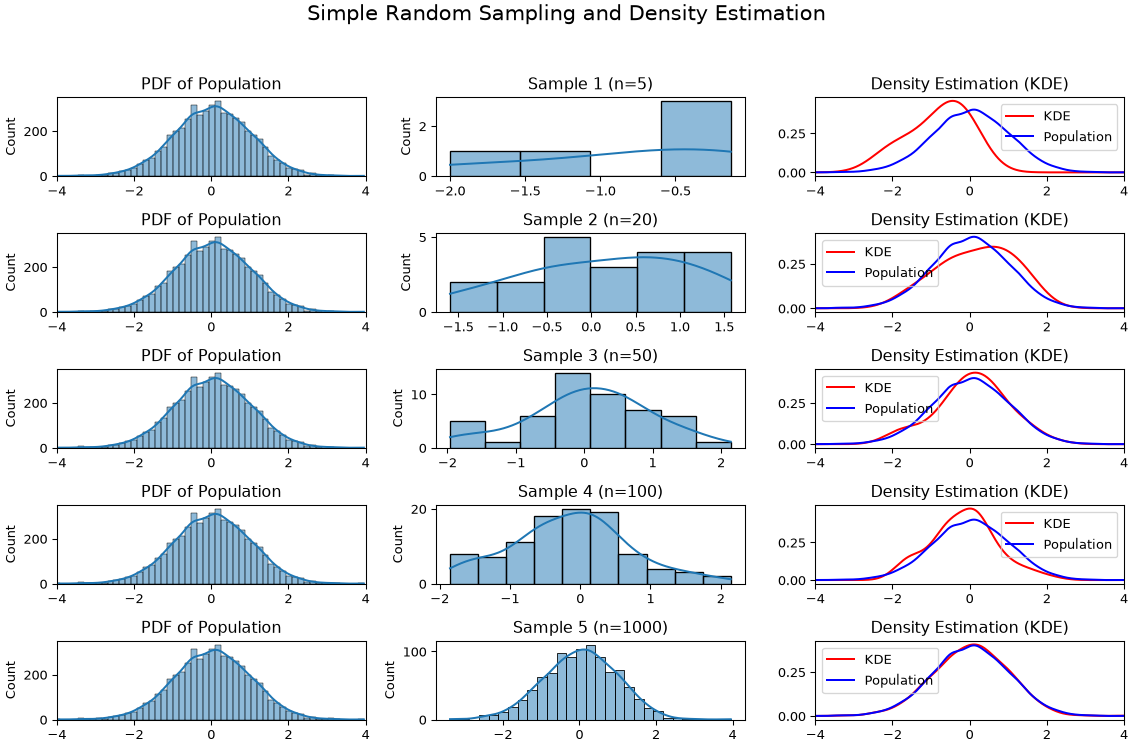

### Stratified Sampling

Sometimes, the population under study is **heterogeneous**, meaning it
contains distinct subgroups with different characteristics. In such
cases, **simple random sampling** may fail to capture the diversity of
the population, leading to **under-representation** of certain groups.

For example, suppose we hypothesize that the variable `Occupation`
influences voting preferences. If we randomly sample from the entire
population, we might unintentionally select too few individuals from
certain occupations, skewing our results.

To address this, we can use **stratified sampling**. This involves:

-   Dividing the population into **homogeneous subgroups** (*strata*)
    based on a relevant variable, such as `Occupation`
-   Performing **random sampling within each stratum**, ensuring
    proportional representation

This method improves representativeness but requires **prior knowledge
or assumptions** about the population structure.

The figure below shows a heterogeneous population, a sample obtained via
uniform random sampling, and a sample obtained via stratified sampling.

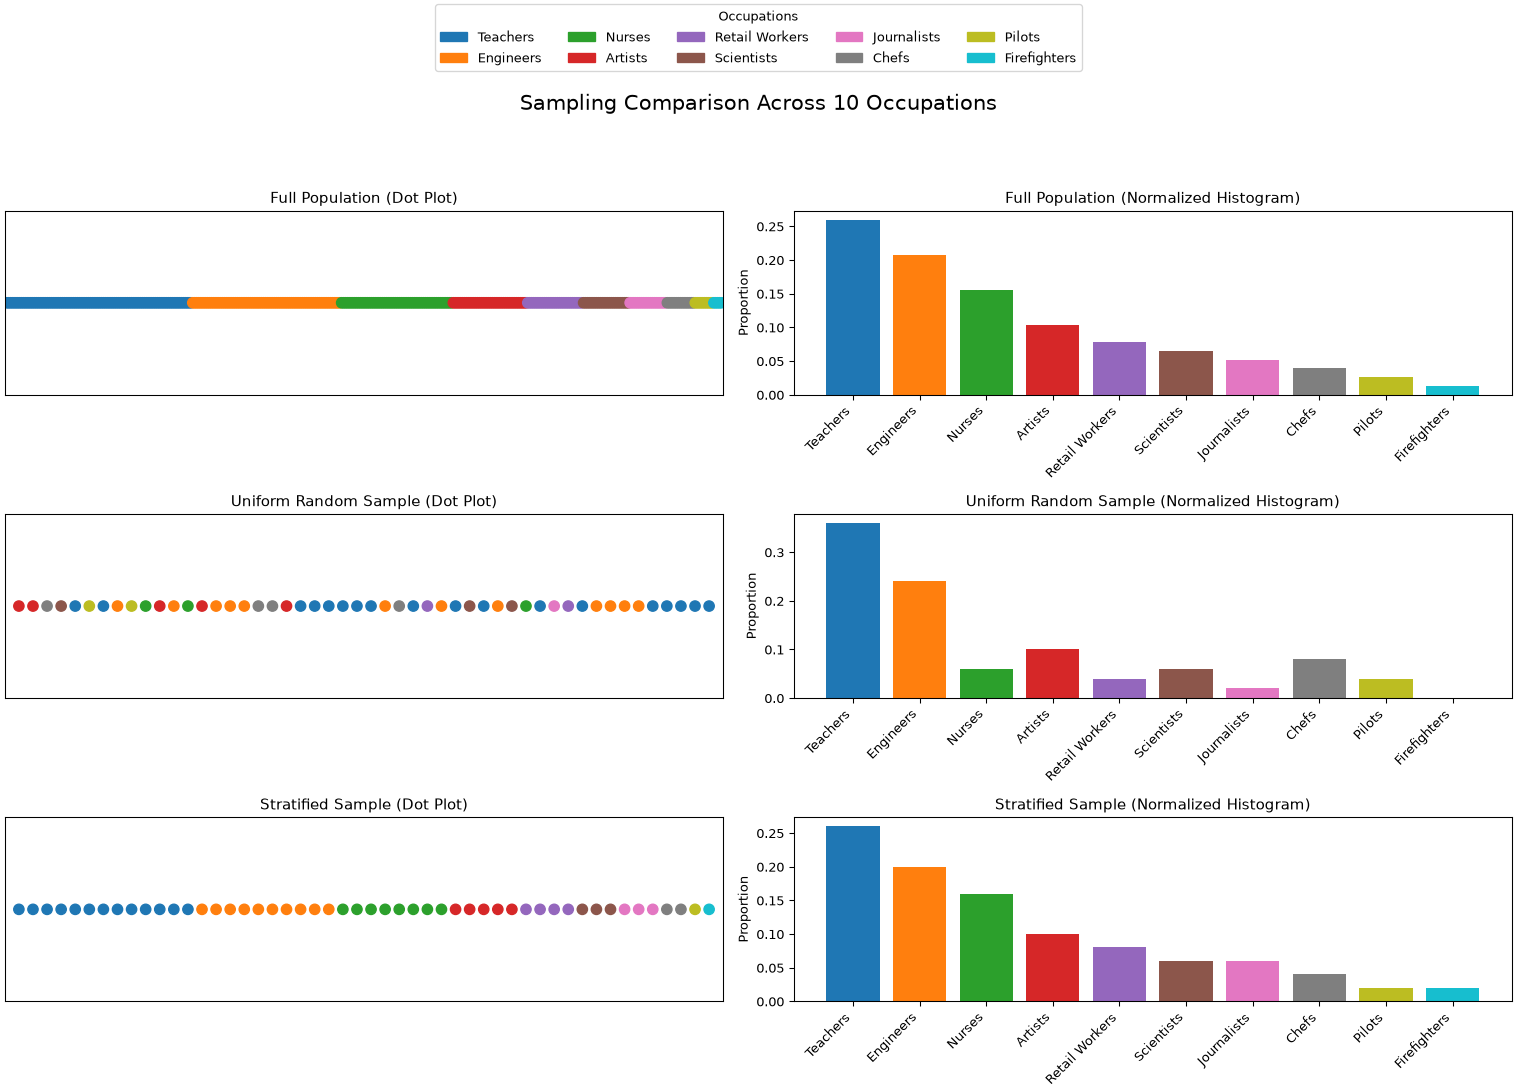

### Sampling in Python

In Python we can easily sample from known distributions using numpy
`random` module, as shown in the example below:

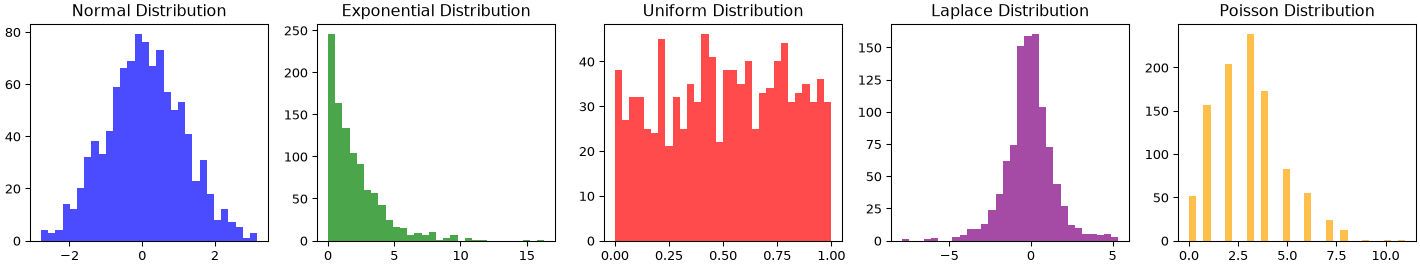

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Set the sample size
sample_size = 1000

# Sample from the Normal (Gaussian) Distribution
mean_normal = 0
std_dev_normal = 1
samples_normal = np.random.normal(mean_normal, std_dev_normal, sample_size)

# Sample from the Exponential Distribution
rate_exponential = 0.5
samples_exponential = np.random.exponential(1/rate_exponential, sample_size)

# Sample from the Uniform Distribution
low_uniform = 0
high_uniform = 1
samples_uniform = np.random.uniform(low_uniform, high_uniform, sample_size)

# Sample from the Laplace Distribution
loc_laplace = 0
scale_laplace = 1
samples_laplace = np.random.laplace(loc_laplace, scale_laplace, sample_size)

# Sample from the Poisson Distribution
lam_poisson = 3
samples_poisson = np.random.poisson(lam_poisson, sample_size)

# Create histograms to visualize the distributions
plt.figure(figsize=(15, 3))

plt.subplot(1, 5, 1)
plt.hist(samples_normal, bins=30, color='blue', alpha=0.7)
plt.title('Normal Distribution')

plt.subplot(1, 5, 2)
plt.hist(samples_exponential, bins=30, color='green', alpha=0.7)
plt.title('Exponential Distribution')

plt.subplot(1, 5, 3)
plt.hist(samples_uniform, bins=30, color='red', alpha=0.7)
plt.title('Uniform Distribution')

plt.subplot(1, 5, 4)
plt.hist(samples_laplace, bins=30, color='purple', alpha=0.7)
plt.title('Laplace Distribution')

plt.subplot(1, 5, 5)
plt.hist(samples_poisson, bins=30, color='orange', alpha=0.7)
plt.title('Poisson Distribution')

plt.tight_layout()
plt.show()

We can also sample from an existing sample to obtain a **subsample**.
This can be done starting from a dataset. For instance, let us consider
the *weight-height* dataset:

In [5]:
import pandas as pd
data=pd.read_csv(DATA + "height_weight.csv")
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4231 entries, 0 to 4230
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sex     4231 non-null   object 
 1   BMI     4231 non-null   float64
 2   height  4231 non-null   float64
 3   weight  4231 non-null   float64
dtypes: float64(3), object(1)
memory usage: 132.3+ KB

We can obtain a subsample of 1000 observations as follows:

In [6]:
sample1=data.sample(1000)
sample1.info()
sample1.head()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 129 to 3443
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sex     1000 non-null   object 
 1   BMI     1000 non-null   float64
 2   height  1000 non-null   float64
 3   weight  1000 non-null   float64
dtypes: float64(3), object(1)
memory usage: 39.1+ KB

Sampling will be random and uniform. As can be seen the indexes of the
rows are shuffled. By default, Pandas will sample without replacement.
We can sample with replacement specifying `replace=True`. For instance,
we can obtain a larger sample (with repetitions) as follows:

In [7]:
sample2=data.sample(5000, replace=True)
sample2.info()
sample2.head()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 1637 to 1037
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sex     5000 non-null   object 
 1   BMI     5000 non-null   float64
 2   height  5000 non-null   float64
 3   weight  5000 non-null   float64
dtypes: float64(3), object(1)
memory usage: 195.3+ KB

We can perform stratified sampling as follows:

In [8]:
# Define the stratification variable
strata_variable = 'sex'

# Number of samples per stratum
samples_per_stratum = 500

# Draw the same number of rows from every stratum. `.sample()` on a groupby does
# this directly, and unlike `.apply()` it keeps the grouping column.
stratified_sample = (
    data.groupby(strata_variable, group_keys=False)
        .sample(samples_per_stratum)
        .reset_index(drop=True)
)

# Inspect the result
stratified_sample.info()
stratified_sample.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sex     1000 non-null   object 
 1   BMI     1000 non-null   float64
 2   height  1000 non-null   float64
 3   weight  1000 non-null   float64
dtypes: float64(3), object(1)
memory usage: 31.4+ KB

Note that, with this method, sampled observations will be sorted by
`sex`. To get rid of this bias, we can shuffle the dataframe as follows:

In [9]:
stratified_sample = stratified_sample.iloc[np.random.choice(len(stratified_sample), len(stratified_sample), replace=False)]
stratified_sample.head()

Males and females will be perfectly balanced by design in this
stratified sample:

In [10]:
stratified_sample['sex'].value_counts()

sex
M    500
F    500
Name: count, dtype: int64

## Sampling Distribution of the Mean

Let’s consider this problem:

> A bakery sells packages of cookies labeled as weighing **1kg**. Due to
> small variations in the production process, the actual weight of each
> package may differ slightly. To ensure quality, the bakery wants to
> verify that the average weight is close to the target.

We take a **random sample of $n = 1000$** packages and measure their
weights $x_1, x_2, \ldots, x_n$. We compute the sample mean:

$$
\overline{x} = \frac{x_1 + x_2 + \ldots + x_n}{n} = 1000.2 \text{g}
$$

This value is close to the target of 1000g, so we might conclude that
the production process is accurate. But what if we took another sample?
Would we get the same result?

$$
\overline{x} = \frac{x_1 + x_2 + \ldots + x_n}{n} = 999.7 \text{g}
$$

This is still close to the target, but slightly lower than before. If we
repeated this process many times, we would get a **distribution of
sample means**.

We treat each package’s weight as a **random variable** $X_i$, with:

$$
E[X_i] = \mu \\
Var[X_i] = \sigma^2
$$

where $\mu$ and $\sigma$ are the **true mean and standard deviation** of
the population.

The sample mean $\overline{X}$ is also a random variable:

$$
\overline{X} = \frac{X_1 + X_2 + \ldots + X_n}{n}
$$

Note that, while we cannot make assumptions for the individual $X_i$,
for the **central limit theorem**, we know that:

> For large $n$, the distribution of $\overline{X}$ will be
> approximately **normal**, regardless of the shape of the original
> data.

We can derive the expected value, variance and standard deviation of $X$
as follows:

$$
E[\overline{X}] = E\left[\frac{1}{n} \sum_{i=1}^n X_i\right] = \frac{1}{n} \sum_{i=1}^n E[X_i] = \mu
$$

$$
Var[\overline{X}] = Var\left[\frac{1}{n} \sum_{i=1}^n X_i\right] = \frac{1}{n^2} \sum_{i=1}^n Var[X_i] = \frac{\sigma^2}{n}
$$

$$
Std[\overline{X}] = \frac{\sigma}{\sqrt{n}}
$$

We note that: - The **expected value of the sample means** (the mean of
the means) converges to the **mean of the population**. This is the
value we want to estimate: the actual average weight of packages. - The
**standard deviation of the distribution** quantifies the precision
according to which we can measure the mean. A small standard deviation
indicates that sample means have small variability, so a single estimate
will likely be closer to the true mean and hence more reliable.

This is exemplified by the following figure:

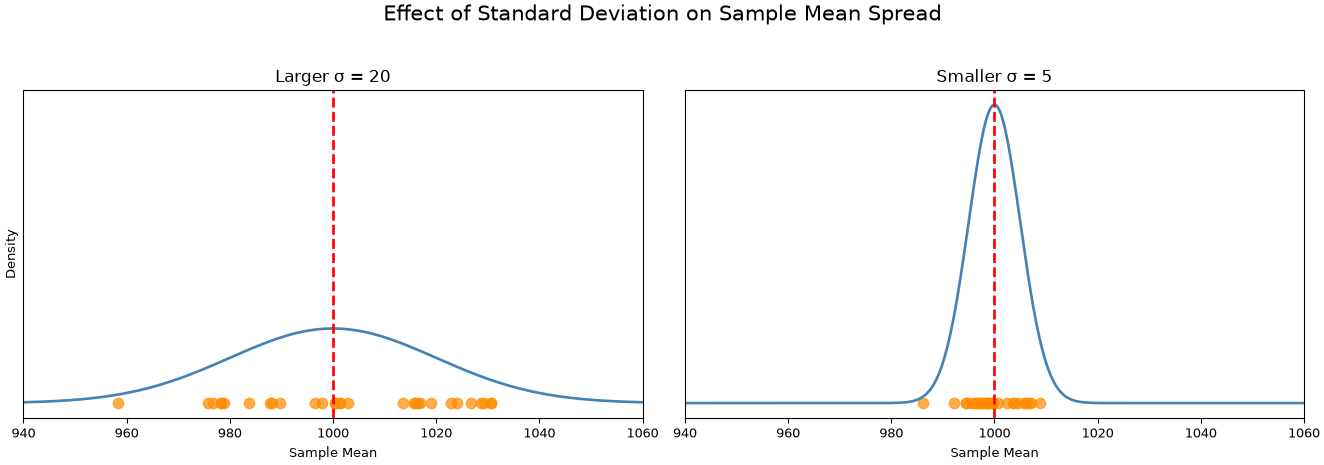

### Standard Error

While useful to quantify our precision in the estimation of the true
mean, the standard deviation depends on the variance of the population,
which is unknown.

In practice, we estimate it using the sample standard deviation:

$$
s_{n-1} = \sqrt{\frac{1}{n-1} \sum_{i=1}^n (x_i - \overline{x})^2}
$$

and define the Standard Error (SE) as follows:

$$
SE(\overline{x}) = \frac{s_{n-1}}{\sqrt{n}}
$$

Similar to the standard deviation, **the standard error quantifies our
uncertainty in the estimation of the true mean**.

Note that the standard error is **inversely proportional to the square
root of the sample size**:

$$
SE(\overline{x}) \propto \frac{1}{\sqrt{n}}
$$

This relationship is common in many statistical estimators. It means
that:

-   If we **double the sample size**, the error **reduces by about
    30%**.
-   To **halve the error**, we need to **quadruple the sample size**.

This is a key insight: reducing uncertainty requires much more data than
we might expect.

The standard error tells us how close our sample mean $\overline{x}$ is
likely to be to the true mean $\mu$. A small standard error means that
repeated samples will yield similar results, and our estimate is
precise. A large standard error means more variability and less
confidence in the estimate.

This is shown in the graph below:

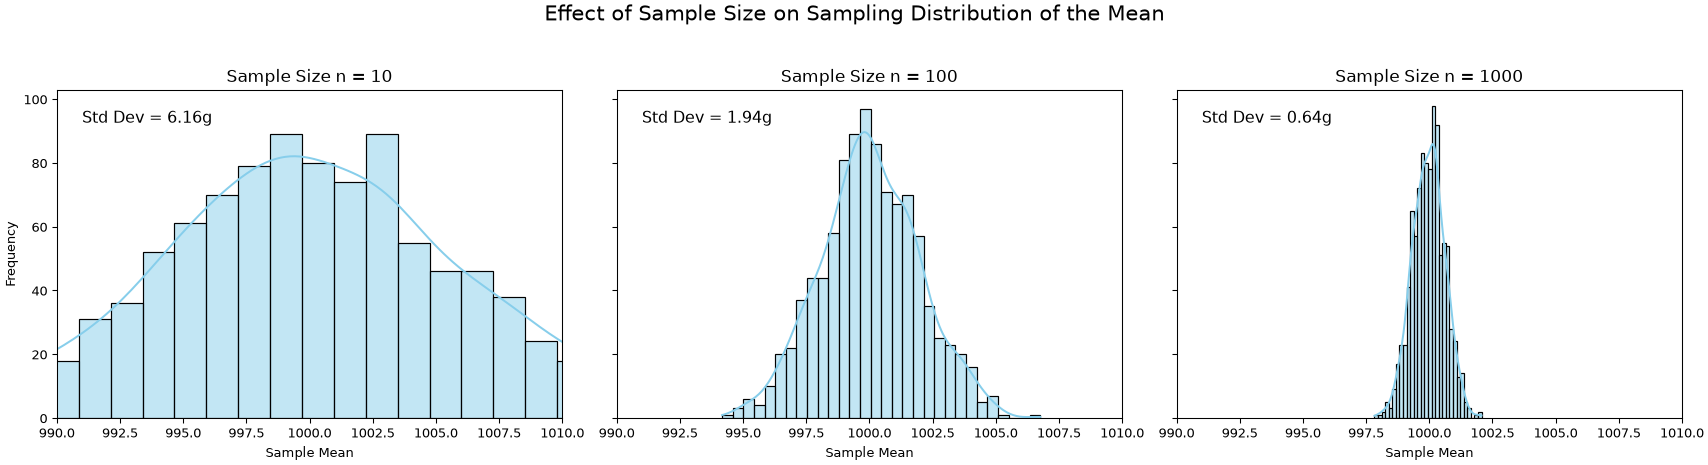

This figure illustrates how **sample size affects the precision of the
sample mean**. Each panel shows the distribution of sample means
obtained by repeatedly sampling from the same population (mean = 1000g,
standard deviation = 20g), but with different sample sizes:

-   **Left (n = 10)**: The distribution is wide, indicating high
    variability. Small samples lead to more fluctuation in the estimated
    mean.
-   **Center (n = 100)**: The distribution narrows, showing improved
    stability. The sample means are more tightly clustered around the
    true mean.
-   **Right (n = 1000)**: The distribution is very narrow. Large samples
    yield highly consistent estimates, with minimal deviation from the
    true mean.

This visual reinforces the key idea that **larger samples reduce the
standard error**, making our estimates more reliable. The spread of the
sampling distribution shrinks proportionally to $1/\sqrt{n}$.

### t-Student Distribution

When $n$ is small, the distribution of $\overline{X}$ is **not exactly
normal**. Instead, we use the **t-Student distribution**, which accounts
for extra uncertainty:

$$
t_{n-1} = \frac{\overline{X} - \mu}{s_{n-1} / \sqrt{n}}
$$

This follows a t-distribution with $n - 1$ degrees of freedom. The
t-distribution looks like a Gaussian but has **heavier tails**, meaning
more room for extreme values. As $n$ increases, the t-distribution
**converges to the normal distribution**.

> Note that the t-Student distribution is obtained by applying
> standardization using the standard error rather than the standard
> deviation (which is unknown).

The relationship between a t-Student and Gaussian distribution is shown
in the figure below:

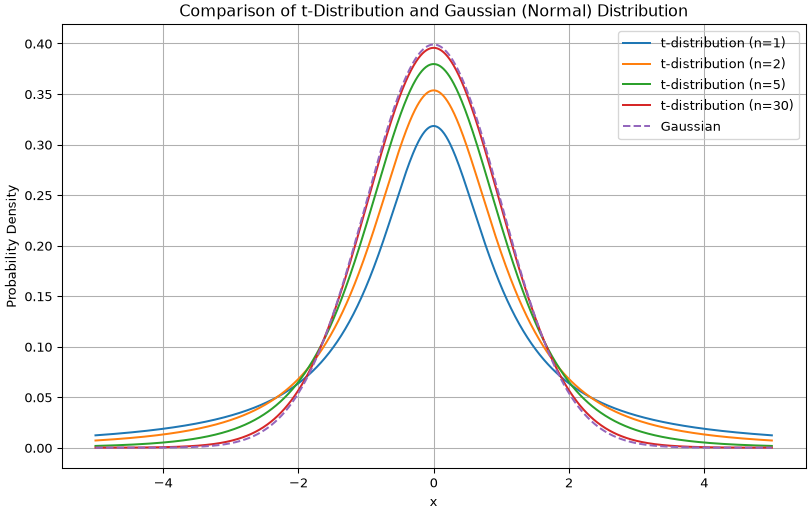

As $n$ gets larger, the t-Distribution approximates a Gaussian
distribution.

We can now characterize how the means will distribute. In particular,
**for large values of $n$, sample means will distribute according to a
Gaussian distribution with standard deviation equal to the sample
standard deviation**.

## Confidence Intervals

Let’s return to our bakery example. We want to estimate the **true
average weight** $\mu$ of cookie packages, which are labeled as 1kg. We
take a sample of $n = 1000$ packages and compute:

$$
\overline{x} = 1000.2 \text{g}
$$

This is our estimate of the true mean. However, we know that this value
may vary depending on the sample we draw. If we took another sample, we
might get a slightly different result. It is interesting to define the
**bounds of such variation**, to understand where the true mean $\mu$ is
likely to be found relative to our estimate $\overline{x}$.

Remember that the sample mean $\overline{X}$ follows a **Gaussian
distribution** centered at $\mu$ due to the **Central Limit Theorem**.

We also know that about $68.3\%$ of the density of the Gaussian
distribution will be within $\mu-\sigma$ and $\mu+\sigma$, so we can
write:

$$P\left(\mu-\sigma \leq \overline{x} \leq \mu+\sigma\right) = 0.683$$

Which means that, if we perform several independent samplings, with
sample size $n$, the probability of obtaining a sample mean
$\overline{x}$ in the range $[\mu-\sigma, \mu+\sigma]$ is $68.3\%$.

It is easy to show that:

$$\overline{x} \in [\mu-\sigma, \mu+\sigma] \Leftrightarrow \mu \in [\overline{x}-\sigma, \overline{x}+\sigma]$$

This is graphically shown in the plot below. The blue segment is the one
of bounds $[\mu-\sigma, \mu+\sigma]$. Note that, all times a point
$\overline{x}$ happens to be in the blue segment centered around $\mu$,
then $\mu$ is in the segment centered around $\overline{x}$.

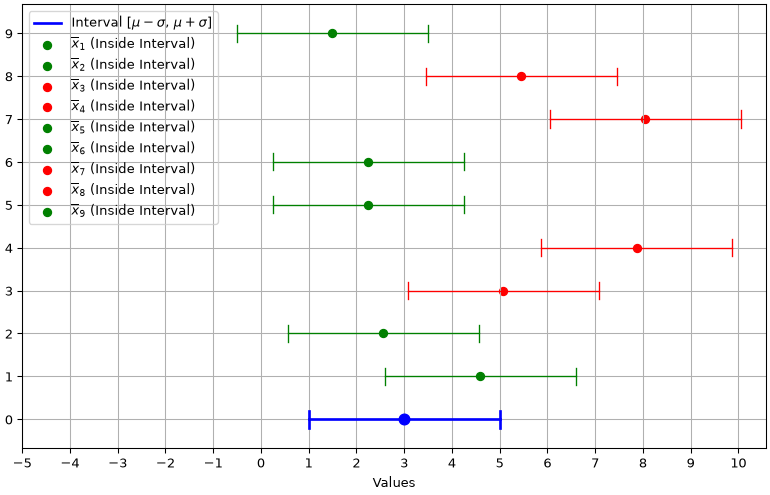

This allows us to write:

$$P\left(\overline{x}-\sigma \leq \mu \leq \overline{x}+\sigma\right) = 0.683$$

which has a powerful interpretation:

> If we draw many independent samples of size $n$ and compute
> $\overline{x}$ from the samples, the true mean $\mu$ will lie in the
> interval $[\overline{x}-\sigma, \overline{x}+\sigma]$ $68.3\%$ of the
> times

Alternatively

> We can say with a confidence of $68.3\%$ that the true mean will be in
> the $[\overline{x}-\sigma, \overline{x}+\sigma]$ interval.

In this context, $[\overline{x}-\sigma, \overline{x}+\sigma]$ is called
a **confidence interval**.

We still have to compute actual numbers for our confidence interval, but
we don’t have the standard deviation $\sigma$. In practice, we replace
it with the standard error and obtain the confidence interval:

$$[\overline{x}-SE(\overline{x}), \overline{x}+SE(\overline{x})]$$

We note that $68.3$ is a very peculiar number and also a relatively low
probability. In general, given a chosen percentage $p$, that we call a
**confidence level**, we can obtain a number $\beta$ such that:

$$P\left(\overline{x}-\beta \sigma \leq \mu \leq \overline{x}+\beta \sigma\right) = p$$

leading to the following confidence interval:

$$[\overline{x}-\beta SE(\overline{x}), \overline{x}+\beta SE(\overline{x})]$$

Alternatively, we will say that we chose a **significance level**
$\alpha=0.05$, which quantifies the number of times we admin the true
mean will be out of the confidence interval.

It is very common to set $\alpha=0.05$, which leads to $\beta=1.96$ and
the following confidence interval:

$$[\overline{x}-1.96 \cdot SE(\overline{x}), \overline{x}+1.96 \cdot SE(\overline{x})]$$

### Example: Confidence Interval for Cookie Weights

Let’s suppose we want to estimate the **true average weight** $\mu$ of
cookie packages sold by a bakery. We take a sample of $n = 1000$
packages and compute the sample mean:

$$
\overline{x} = 1000.2 \text{g}
$$

We also compute the sample standard deviation:

$$
s_{n-1} = 0.1 \text{g}
$$

Our estimate $\overline{x}$ is close to the labeled weight of 1000g, but
we know it may vary depending on the sample. It is useful to define the
**bounds of such variation**, to understand where the true mean $\mu$ is
likely to be found relative to our estimate.

To do this, we build a **confidence interval**. We first choose a
**confidence level**. For example, if we want to be **95% confident**,
we define:

$$
\alpha = 0.05
$$

This means we accept a $5\%$ chance that the true mean lies outside our
interval. Since the sample mean $\overline{X}$ follows a **Gaussian
distribution**, we know that **95% of the density** lies within $1.96$
standard deviations from the mean. So we write:

$$
P\left(\overline{X} - 1.96 \cdot SE(\overline{X}) \leq \mu \leq \overline{X} + 1.96 \cdot SE(\overline{X})\right) = 0.95
$$

We compute the standard error:

$$
SE(\overline{x}) = \frac{s_{n-1}}{\sqrt{n}} = \frac{0.1}{\sqrt{1000}} = 0.0032 \text{g}
$$

Then the confidence interval becomes:

$$
[1000.2 - 1.96 \cdot 0.0032,\ 1000.2 + 1.96 \cdot 0.0032] = [1000.194,\ 1000.206]
$$

This means we are **95% confident** that the true average weight of
cookie packages lies between **1000.194g and 1000.206g**.

Since the interval is narrow, we can say that our estimate is precise.
If the sample size were smaller, the interval would be wider, reflecting
greater uncertainty in the estimate.

### Computing Confidence Intervals in Practice

We have seen how to compute confidence interval “by hand” in the case of
the estimation of proportions (defect rate).In practice, depending on
the quantities for which we want to estimate confidence bounds, we will
need to use different distributions. For instance, when estimating
means, we will have to use the t-Student distribution with $n-1$ degrees
of freedom. We will not see all methods in detail, but the main
libraries implement all confidence bounds estimation procedure for us.

The main estimation procedures are related to: \* Estimation of
confidence bounds for means; \* Estimation of confidence bounds for
variances; \* Estimation of confidence bounds for proportions.

We will see how to compute these practically in the laboratory sessions.

#### Confidence Intervals for Means

We can compute confidence intervals for the estimation of means with
`scipy`. Let us see how to compute confidence intervals for the mean of
`height`:

In [15]:
from scipy import stats
mean = data['height'].mean()
std = np.std(data['height'])
standard_error = std/np.sqrt(len(data))

confidence_level = 0.95

interval = stats.norm.interval(confidence_level, loc=mean, scale=standard_error)

print(f"Estimated mean: {mean:0.2f}")
print(f"Standard deviation of the sample: {std:0.2f}")
print(f"Standard error of the sample: {standard_error:0.2f}")
print(f"Confidence interval: [{interval[0]:0.2f}, {interval[1]:0.2f}]")

Estimated mean: 169.89
Standard deviation of the sample: 9.96
Standard error of the sample: 0.15
Confidence interval: [169.59, 170.19]

Let us set the confidence level to $0.99$:

In [16]:
from scipy import stats
mean = data['height'].mean()
std = np.std(data['height'])
standard_error = std/np.sqrt(len(data))

confidence_level = 0.99

interval = stats.norm.interval(confidence_level, loc=mean, scale=standard_error)

print(f"Estimated mean: {mean:0.2f}")
print(f"Standard deviation of the sample: {std:0.2f}")
print(f"Standard error of the sample: {standard_error:0.2f}")
print(f"Confidence interval: [{interval[0]:0.2f}, {interval[1]:0.2f}]")

Estimated mean: 169.89
Standard deviation of the sample: 9.96
Standard error of the sample: 0.15
Confidence interval: [169.50, 170.29]

#### Confidence Intervals for Variances

To compute confidence intervals for the estimation of variances, we have
to use the $\chi^2$ distribution:

In [17]:
import numpy as np
from scipy import stats

# Set the desired confidence level
confidence_level = 0.95  # Change this to the desired confidence level (e.g., 0.95 for 95% confidence)

# Calculate the confidence interval for the population variance
confidence_interval = stats.chi2.interval(confidence_level, df=len(data) - 1)

# Calculate the sample variance
sample_variance = np.var(data['height'], ddof=1)  # ddof=1 for sample variance

# Calculate the lower and upper bounds of the confidence interval
variance_lower = (len(data) - 1) * sample_variance / confidence_interval[1]
variance_upper = (len(data) - 1) * sample_variance / confidence_interval[0]

print(f"Sample Variance: {sample_variance:.2f}")
print(f"Confidence Interval for Variance: ({variance_lower:.2f}, {variance_upper:.2f})")

Sample Variance: 99.13
Confidence Interval for Variance: (95.04, 103.49)

#### Confidence Intervals for Proportion

Let us see how to compute confidence intervals for the proportion of
females over males:

In [18]:
import statsmodels.api as sm
import numpy as np

females = data['sex'].value_counts()['F']
total = len(data)

# Set the desired confidence level
confidence_level = 0.95  # Change this to the desired confidence level (e.g., 0.95 for 95% confidence)

# Calculate the proportion (sample proportion)
proportion = females / total

# Compute the confidence interval for the proportion
conf_interval = sm.stats.proportion_confint(females, total, alpha=1 - confidence_level, method='normal')

print(f"Sample Proportion: {proportion:.2f}")
print(f"Confidence Interval for Proportion: ({conf_interval[0]:.2f}, {conf_interval[1]:.2f})")

Sample Proportion: 0.54
Confidence Interval for Proportion: (0.53, 0.56)

### Bootstrapping: Inference Through Resampling

So far, we’ve built confidence intervals using formulas that rely on the
Central Limit Theorem and assumptions about the underlying distribution
(e.g., normality). But **what if our sample size is small**, the
distribution is clearly not normal, or **we want to find a confidence
interval for a statistic where no simple formula exists (like the
median)**?

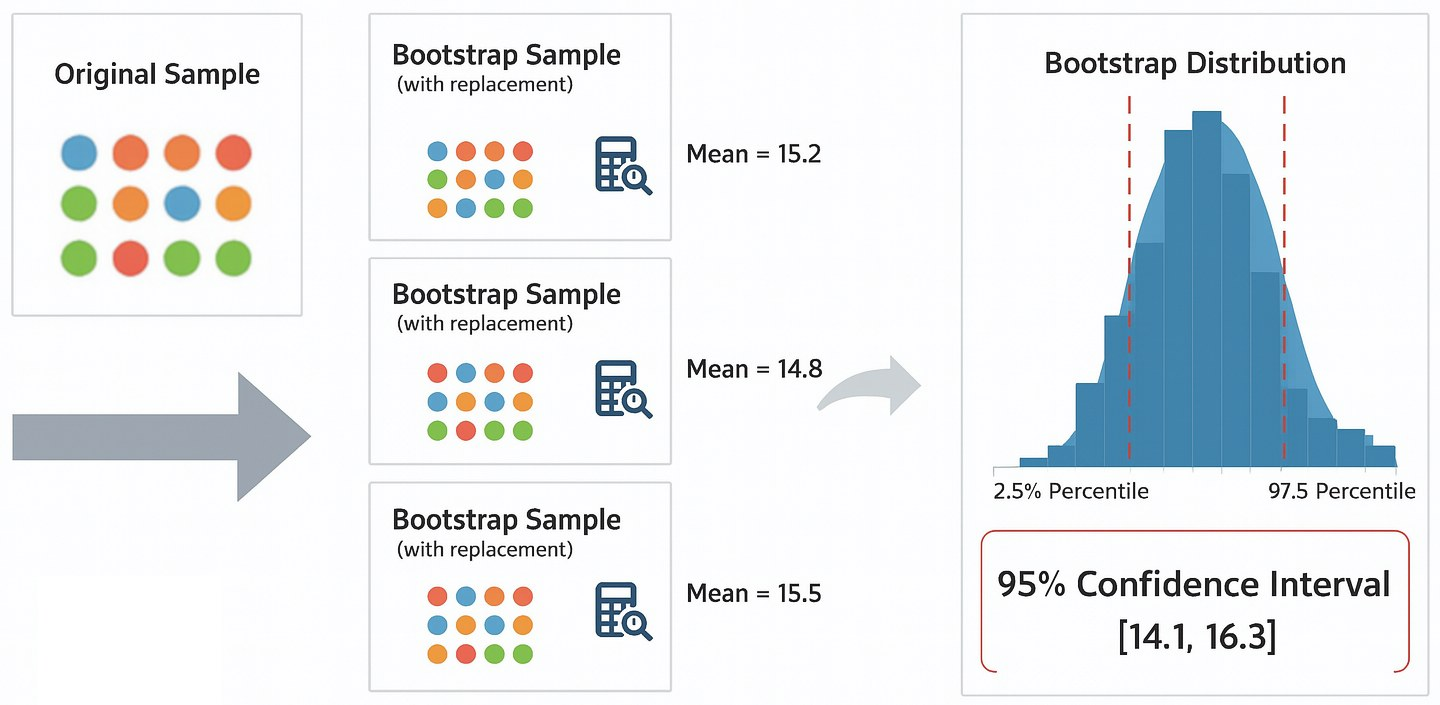

This is where **bootstrapping** comes in. It’s a powerful computational
method that allows us to estimate the sampling distribution of any
statistic using only our original sample. The name comes from the phrase
“to pull oneself up by one’s own bootstraps”, reflecting the idea that
we use the sample itself to learn about its own uncertainty.

The core idea is to treat the **sample as a stand-in for the
population**. We then simulate the process of drawing new samples by
resampling *from our own sample*.

The process is straightforward and relies on computation rather than
complex formulas:

1.  **Start with your original sample** of size $n$.
2.  **Create a “bootstrap sample”** by drawing $n$ observations from
    your original sample **with replacement**. This new sample will be
    the same size as the original, but some data points may appear
    multiple times, while others may not appear at all.
3.  **Calculate the statistic of interest** (e.g., mean, median,
    standard deviation) for this bootstrap sample.
4.  **Repeat steps 2 and 3 thousands of times** (e.g., 10,000 times),
    recording the statistic each time.
5.  **Build the bootstrap distribution**. The collection of all the
    statistics you calculated forms an empirical sampling distribution.
    We can now use this distribution to estimate properties like the
    standard error or confidence intervals.

For a 95% confidence interval, we can simply take the 2.5th and 97.5th
percentiles of our bootstrap distribution.

### Example: Bootstrap Confidence Interval for Mean Height

Let’s use bootstrapping to find the 95% confidence interval for the mean
height in our `height_weight` dataset.

In [19]:
import numpy as np
import pandas as pd
from scipy import stats

# Load the dataset
data = pd.read_csv(DATA + "height_weight.csv")
original_sample = data['height']

# The data must be passed as a sequence (e.g., a tuple)
data_tuple = (original_sample,)

# Use scipy.stats.bootstrap to perform the resampling and calculate the interval
# We pass the data, the statistic to compute (np.mean), and the number of resamples.
bootstrap_result = stats.bootstrap(data_tuple, np.mean, n_resamples=10000, confidence_level=0.95)

# Extract the confidence interval from the result object
confidence_interval = bootstrap_result.confidence_interval

print(f"Original sample mean: {original_sample.mean():.2f}")
print(f"SciPy Bootstrap 95% Confidence Interval for the Mean: [{confidence_interval.low:.2f}, {confidence_interval.high:.2f}]")

Original sample mean: 169.89
SciPy Bootstrap 95% Confidence Interval for the Mean: [169.60, 170.19]

## Bias and Variance of Estimators

Let’s return to our bakery example. We want to estimate the **true
average weight** $\mu$ of cookie packages. To do this, we take a sample
of $n$ packages and compute the sample mean:

$$
\overline{x} = \frac{1}{n} \sum_{i=1}^{n} x_i
$$

This formula is called an **estimator** of the population mean. The
value we obtain from a specific sample is called an **estimate**. Since
the sample changes each time we repeat the experiment, the estimate will
vary.

It is useful to study how this estimator behaves across different
samples—specifically, we want to understand its **bias** and
**variance**.

### Bias of an Estimator

Let $X$ be a random variable and let $x = (x_1, x_2, \ldots, x_n)$ be a
sample from the population. Let $T(X)$ be an estimator of a population
quantity $\phi$ (for instance, the mean weight). Then:

$$
T(X) = \frac{1}{n} \sum_{i=1}^{n} x_i
$$

is our estimator for $\phi$. Since the sample changes, $T(X)$ is a
**random variable**.

The **bias** of the estimator is defined as:

$$
Bias_\phi(T(X)) = E[T(X)] - \phi
$$

This measures whether the estimator systematically overestimates or
underestimates the true value. If:

$$
E[T(X)] = \phi
$$

then the estimator is **unbiased**, meaning that, on average, it gives
the correct result.

In our case, the sample mean $\overline{x}$ is an **unbiased estimator**
of the population mean. If we repeated the sampling many times and
averaged all the sample means, we would get a value close to $\mu$.

### Unbiased Estimator for the Variance

To estimate the variance of cookie weights, we may compute:

$$
s_n^2 = \frac{1}{n} \sum_{i=1}^{n} (x_i - \overline{x})^2
$$

This formula is **biased**—it tends to underestimate the true variance
$\sigma^2$. Specifically:

$$
E[s_n^2] = \frac{n-1}{n} \sigma^2
$$

To correct this, we use the **unbiased estimator**:

$$
s_{n-1}^2 = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \overline{x})^2
$$

This is the version we use when estimating the standard error and
building confidence intervals. For large $n$, the difference between
$s_n^2$ and $s_{n-1}^2$ becomes negligible.

### Variance of an Estimator

The **variance** of an estimator tells us how much the estimate
fluctuates across different samples. It is defined as:

$$
Var(T(X)) = E[(T(X) - E[T(X)])^2]
$$

A low variance means that repeated samples give similar results. A high
variance means that estimates are unstable and vary widely.

### Bias-Variance Tradeoff

Ideally, we want an estimator with **low bias** and **low variance**.
This means that: - The estimates are close to each other (low
variance), - And they are close to the true value (low bias).

In practice, we can visualize four scenarios:

-   **Low bias, low variance**: estimates are tightly clustered around
    the true value.
-   **Low bias, high variance**: estimates are scattered but centered
    correctly.
-   **High bias, low variance**: estimates are consistent but
    systematically wrong.
-   **High bias, high variance**: estimates are scattered and
    off-target.

This is often illustrated as a target with darts: the true value is the
bullseye, and each dart is an estimate. The goal is to hit close to the
center, consistently.

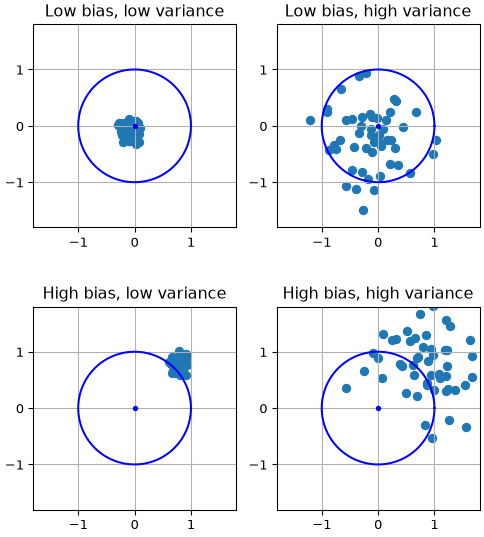

The four cases are: \* Low bias, low variance: all estimates will be
close to the true value; \* Low bias, high variance: in average,
estimates will be close to the true value, but different estimates may
greatly differ; \* High bias, low variance: while different estimates
will be similar, they all are very far away from the true value; \* High
bias, high variance: we don’t have many guarantees - estimates will all
be different, but also far from the real value, even in average.

It’s clear that having low bias and low variance is desirable, but, as
we will see, this is not always easy to achieve. In practice, we’ll see
that in many cases it there is a trade-off between bias and variance,
meaning that **we can tweak our estimator to find a balance between
these two properties**.

## Hypothesis Testing

Confidence intervals provide a range of plausible values for a
population parameter based on a sample. A **hypothesis test**, instead,
is used to **challenge a specific claim** about that parameter. Examples
of hypotheses we might want to test include:

-   The average weight of cookie packages is exactly 1000g.
-   Two different ovens produce cookies with the same average weight.
-   The proportion of underweight packages is below a regulatory
    threshold.

If the hypothesis is rejected, we conclude that the claim is likely
false. Otherwise, we do not have enough evidence to reject it, and we
act as if it were true.

### Hypothesis Testing for Cookie Weights

Let’s return to our bakery. The packaging machine is set to produce
cookie packages weighing **exactly 1000g**. We take a sample of
$n = 1000$ packages and compute:

$$
\overline{x} = 1000.0005 \text{g}, \quad s_{n-1} = 0.01 \text{g}
$$

We assume the small deviation is due to measurement noise or natural
variation, and we are inclined to believe that the **true mean is still
$\mu = 1000$g**.

However, our quality control manager raises a concern: what if the
population mean is **not** 1000g? She proposes a formal test to
challenge the assumption. We define:

-   **Null hypothesis** ($H_0$): the population mean is $\mu_0 = 1000$g
-   **Alternative hypothesis** ($H_a$): the population mean is different
    from 1000g

The null hypothesis is the hypothesis we are trying to reject (what we
are trying to prove). If we do so, then we embrace the alternative
hypothesis.

Before proceeding, we ask what margin of error is acceptable. The
manager says she can tolerate a **5% chance of wrongly rejecting
$H_0$**. This defines our **significance level**:

$$
\alpha = 0.05
$$

We now ask: **how much does our sample mean**
$\overline{x} = 1000.0005g$ **deviate from the assumed mean**
$\mu_0 = 1000g$? More precisely, **what is the probability of observing
a difference this large (or larger) just by chance?**

To answer this, we compute the **test statistic** using the
t-distribution:

$$
t = \frac{\overline{x} - \mu_0}{s_{n-1}/\sqrt{n}} = \frac{1000.0005 - 1000}{0.01 / \sqrt{1000}} = 1.58
$$

This tells us how many standard errors our estimate is away from the
hypothesized mean.

We now ask: **what is the probability of observing a value this extreme
or more extreme, assuming $H_0$ is true?** This is the **p-value**,
defined as:

$$
P(|z| > |t|)
$$

This is the area under the tails of the t-distribution beyond $t$ and
$-t$:

Test statistic (t): 1.5811

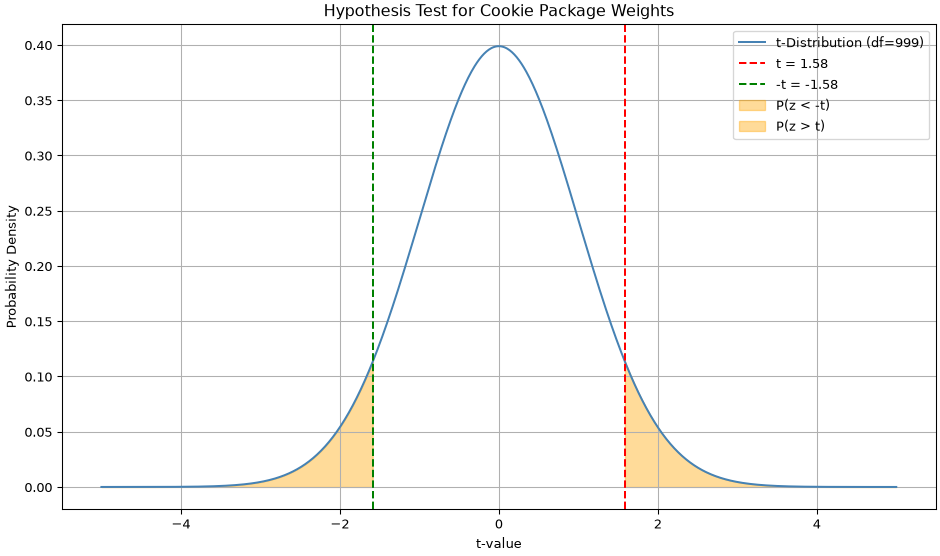

Since the t-Student distribution is symmetrical, we can easily compute
the p-value as:

$$\text{p-value} = 2(1-CDF_t(t))$$

In our case, we obtain:

In [22]:
t_stat = (x_bar - mu_0) / (s / np.sqrt(n))
print(f"{2*(1-t.cdf(t_stat, df, loc=0, scale=1)):0.2f}")

0.11

This is a large number! How to interpret it?

> If the true mean is $\mu=1000$ and we repeat sampling many times
> ($n=1000$), then $11\%$ of the times we obtain a deviation more
> extreme than the observed one.

We now compare this number to the significance level of $5\%$. If we
reject the null hypothesis, we risk to make a mistake $11\%$ of times
(i.e., if we reject with this deviation, we should also reject for the
other $11\%$ of the times that the deviation is larger and we know that
$H_0$ is true), which is above the threshold of $5\%$. Hence, **we
cannot reject the null hypothesis** under these circumstances.

Does this mean that the two means are the same? **We don’t know, the
test does not tell us what to do in this case!** But we may try to
collect more measurements hoping to reduce uncertainty.

We suspect that our sample is too small, so we collect a total of
$n=5000$ examples and obtains:

$$\overline x = 1000.0001$$ $$s_{n-1} = 0.0031$$

The mean has decreased a little and the standard deviation has
decreased. We recompute the statistic and obtain:

2.28

We have a larger (more extreme) statistic. We hence compute our p-value:

0.02

This p-value is now below the threshold of $5\%$. We can now reject the
null hypothesis and conclude that the population mean is different than
$1000g$.

#### Types of Errors in Statistical Tests

Our statistical test provides evidence to either **reject** the null
hypothesis in favor of the alternative or **fail to reject** it.
However, since our decision is based on a sample, not the entire
population, we can never be 100% certain. This uncertainty leads to the
possibility of making two types of errors.

##### Type I Error (False Positive)

A **Type I Error** occurs when we **incorrectly reject a true null
hypothesis**. In other words, we conclude there is an effect or a
difference when, in reality, there isn’t one.

The probability of committing a Type I error the **significance level**
**alpha ($\alpha$)**. When we set a significance level of
$\alpha = 0.05$, we are accepting a 5% risk of making a Type I error.

##### Type II Error (False Negative)

A **Type II Error** occurs when we **fail to reject a false null
hypothesis**. This means we miss a real effect or difference that
actually exists.

##### Summary of Decisions

We can summarize the relationship between our decision and reality in a
table:

|  | **Null Hypothesis ($H_0$) is True** | **Null Hypothesis ($H_0$) is False** |
|:--------------|:----------------------------|:----------------------------|
| **Fail to Reject $H_0$** | ✅ Correct Decision (True Negative) | ❌ **Type II Error** (False Negative) |
| **Reject $H_0$** | ❌ **Type I Error** (False Positive) | ✅ Correct Decision (True Positive) |

#### One-tailed vs Two-tailed Tests

The tests seen above is a “two-tailed test” in which we summed the areas
in the two tails of the distribution. Depending on the form of the
alternative hypothesis, in particular:

-   If the alternative hypothesis has the form $\mu \neq \mu_0$, then we
    want to check when the deviation from the assumed mean is larger
    than the observed one: $P(|x| > |z|)$;
-   If the alternative hypothesis has the form $\mu > \mu_0$, then we
    want to check when the deviation from the assumed mean is positive
    and larger than the observed one: $P(x > z)$;
-   If the alternative hypothesis has the form $\mu < \mu_0$, then we
    want to check when the deviation from the assumed mean is negative
    and smaller than the observed one: $P(x < z)$.

This will affect the computation of the p-value as shown in the
following figure:

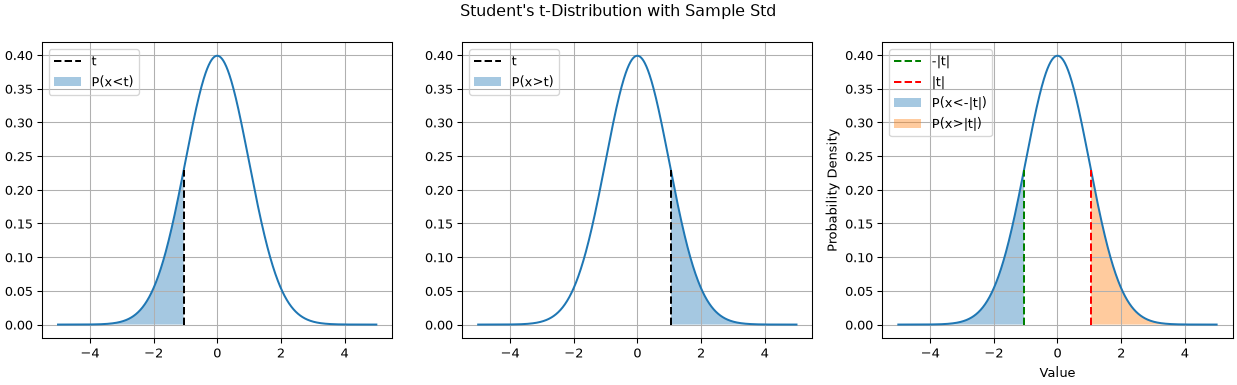

### Hypotheses Tests in General

A hypothesis test generally includes:

-   $H_0$: the **null hypothesis**, e.g., the means of two populations
    are equal;
-   $H_a$: the **alternative hypothesis**, e.g., the means of two
    populations are not equal (this determines if the test is one- or
    two-tailed);
-   a **test statistics** which quantifies how likely it is to reject
    the null hypothesis. The test statistics follows a specific
    distribution which depends on the type of statistical tests we are
    performing. E.g., it can follow a t-Student distribution;
-   a **significance level** $\alpha$ which defines the sensitivity of
    the test. A common value is $\alpha=0.05$, which means that we can
    wrongly reject the null hypothesis $5\%$ of the times when it is in
    fact true. It represents the degree of error that we are willing to
    accept when performing hypothesis testing. Common values are $0.1$,
    $0.05$, $0.01$;
-   the **p-value**: this quantifies the probability of sampling a test
    statistics at least as extreme as the one observed under the null
    hypothesis. In practice, the p-value measures the probability that
    the null hypothesis is true but we are observing test statistic
    leading to rejection nevertheless.

The null hypothesis is rejected if the **p-value is smaller than the
chosen significance level $\alpha$**. We will not see in details all the
possible hypothesis tests, but all of them follow a similar scheme.

### Other Important Tests

In this section, we briefly see the main statistical tests which can be
used in practice, besides the one for means. We will not see how they
are formulated, but we will see how to interpret them. We will see a few
other tests when we’ll talk about linear regression.

#### One Sample T-Test

This is the test for sample means we have previously seen. It is used to
**determine whether the mean of a single sample is significantly
different from a known or hypothesized value.**

This test allows to assess whether a sample has a given mean. Let us
check if the average height in our dataset is equal to $170cm$:

In [26]:
import numpy as np
from scipy import stats

# Define the null hypothesis mean (population mean you want to test against)
null_hypothesis_mean = 170

# Perform a one-sample t-test
t_stat, p_value = stats.ttest_1samp(data['height'], null_hypothesis_mean)

# Set the desired significance level (alpha)
alpha = 0.05

# Check the p-value against the significance level
if p_value < alpha:
    print(f"Reject the null hypothesis. The data provides enough evidence to conclude that the population mean is different from {null_hypothesis_mean}.")
else:
    print(f"Fail to reject the null hypothesis. The data does not provide enough evidence to conclude that the population mean is different from {null_hypothesis_mean}.")

print(f"t-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.4f}")

Fail to reject the null hypothesis. The data does not provide enough evidence to conclude that the population mean is different from 170.
t-statistic: -0.69
P-value: 0.4872

Let us now check if the average height is $170$ among males only:

In [27]:
import numpy as np
from scipy import stats

# Define the null hypothesis mean (population mean you want to test against)
null_hypothesis_mean = 170

data2 = data[data['sex']=='M']

# Perform a one-sample t-test
t_stat, p_value = stats.ttest_1samp(data2['height'], null_hypothesis_mean)

# Set the desired significance level (alpha)
alpha = 0.05

# Check the p-value against the significance level
if p_value < alpha:
    print(f"Reject the null hypothesis. The data provides enough evidence to conclude that the population mean is different from {null_hypothesis_mean}.")
else:
    print(f"Fail to reject the null hypothesis. The data does not provide enough evidence to conclude that the population mean is different from {null_hypothesis_mean}.")

print(f"t-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.4f}")

Reject the null hypothesis. The data provides enough evidence to conclude that the population mean is different from 170.
t-statistic: 45.52
P-value: 0.0000

#### Two Sample T-Test

A two-sample t-test is used to determine if there is a significant
difference between the means of two independent samples. It’s often used
when you want to compare the means of two different populations or
treatments. The test assesses whether the difference between the sample
means is statistically significant or if it could have occurred due to
random chance. Also in this case, the test statistic will follow a
t-Student distribution.

Let us now compare the average heights in two samples we previously
obtained via random sampling. We expect no differences:

In [28]:
import scipy.stats as stats

h1 = sample1['height']
h2 = sample2['height']

# Perform independent two-sample t-test
t_stat, p_value = stats.ttest_ind(h1, h2)

# Define significance level (alpha)
alpha = 0.05

print(f"Test statistic: {t_stat:0.2f}")
print(f"Significance level: {alpha:0.2f}")
print(f"P-value: {p_value:0.2f}")

# Comment on result
if p_value < alpha:
    print("Conclusion: there is a significant difference between the mean exam scores of the two classes.")
else:
    print("Conclusion: there is no significant difference between the mean exam scores of the two classes.")

Test statistic: -0.47
Significance level: 0.05
P-value: 0.64
Conclusion: there is no significant difference between the mean exam scores of the two classes.

In [29]:
import pandas as pd
hw=pd.read_csv(DATA + "height_weight.csv")
hw['height'] = (hw['height']/2.54).astype(int)
hw['weight'] = hw['weight']/2.205
hw

4231 rows × 4 columns

If we compute the average `BMI` for males and females we obtain:

In [30]:
hw.groupby('sex')['BMI'].mean()

sex
F    26.929287
M    27.684959
Name: BMI, dtype: float64

We see a small difference. Is this due to chance or is it significant?
If we run a two-sample t-test, we obtain the following results:

In [31]:
import scipy.stats as stats

male_bmi = hw[hw['sex']=='M']['BMI']
female_bmi = hw[hw['sex']=='F']['BMI']

# Perform independent two-sample t-test
t_stat, p_value = stats.ttest_ind(male_bmi, female_bmi)

# Define significance level (alpha)
alpha = 0.05

print(f"Test statistic: {t_stat:0.2f}")
print(f"Significance level: {alpha:0.2f}")
print(f"P-value: {p_value:0.2f}")

# Comment on result
if p_value < alpha:
    print("Conclusion: there is a significant difference between the two means.")
else:
    print("Conclusion: there is no significant difference between the two means.")

Test statistic: 4.64
Significance level: 0.05
P-value: 0.00
Conclusion: there is a significant difference between the two means.

#### Chi-Square Test for Independence

The Chi-Square Test for Independence is a statistical test used to
determine whether there is an association or independence between two or
more categorical variables. This test is particularly useful when we
want to assess whether changes in one categorical variable are related
to changes in another categorical variable. The typical scenario is to
set up a contingency table to compare the observed frequencies (counts)
of the joint categories of the two variables to the expected frequencies
that would occur under the assumption of independence.

The null hypothesis for the Chi-Square Test for Independence is that
**there is no association between the two categorical variables** (they
are independent), while the alternative hypothesis suggests that there
is an association (they are dependent).

The test statistics follows a Chi-square distribution (we won’t see the
details) in this case.

Let’s consider the Titanic dataset:

In [32]:
import pandas as pd
titanic = pd.read_csv(DATA + "titanic.csv",
                     index_col='PassengerId')
titanic

891 rows × 11 columns

Let’s consider the following contingency table:

In [33]:
contingency_table = pd.crosstab(titanic['Pclass'], titanic['Survived'])
contingency_table

We can visualize the distributions of Survived in the three classes for
more clarity:

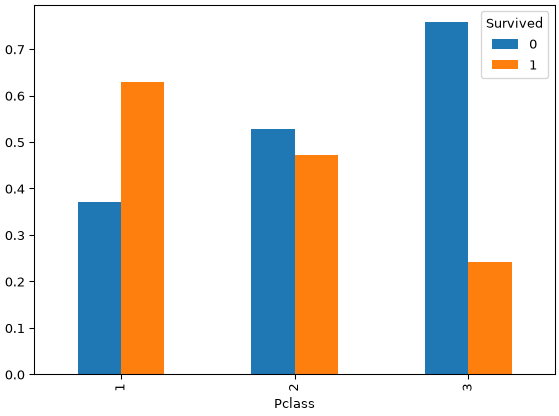

In [34]:
from matplotlib import pyplot as plt
pd.crosstab(titanic['Pclass'], titanic['Survived'], normalize=0).plot.bar()
plt.show()

We expect some form of correlation between the two variables. Indeed,
the chi-square statistics and Cramer V statistics are:

In [35]:
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association

print(f"Chi-square statistic: {chi2_contingency(contingency_table).statistic:0.2f}")
print(f"Cramer V statistic: {association(contingency_table):0.2f}")

Chi-square statistic: 102.89
Cramer V statistic: 0.34

We have numbers different from zero, but **is this due to chance or is
it statistically significant**? If we run a chi-square contingency test:

In [36]:
import seaborn as sns
import pandas as pd
from scipy.stats import chi2_contingency

# Perform the Chi-Square Test for Independence
chi2, p, _, _ = chi2_contingency(contingency_table)

# Set the significance level (alpha)
alpha = 0.05

# Print the results
print("Chi-Square Statistic:", chi2)
print("p-value:", p)

# Interpret the results
if p < alpha:
    print("\nThere is a significant association between 'Pclass' and 'survived'.")
else:
    print("\nThere is no significant association between 'Pclass' and 'survived'.")

Chi-Square Statistic: 102.88898875696056
p-value: 4.549251711298793e-23

There is a significant association between 'Pclass' and 'survived'.

#### Chi-Square Goodness-of-Fit Test

The Chi-Square Goodness of Fit test is a statistical test used to
determine whether observed categorical data (frequencies) fit a
specified distribution or expected frequencies. This test is often used
to assess whether the observed data deviates significantly from a
hypothesized distribution. The typical scenario is to compare observed
frequencies with expected frequencies based on a theoretical model or
prior knowledge.

The null hypothesis for the Chi-Square Goodness of Fit test is that
**there is no significant difference between the observed and expected
frequencies**, meaning the observed data fits the specified
distribution. The alternative hypothesis suggests that there is a
significant difference.

The test statistics follows a Chi-square distribution in this case.

Let us consider the Titanic dataset again. We know that the distribution
of `Sex` among passengers is biased:

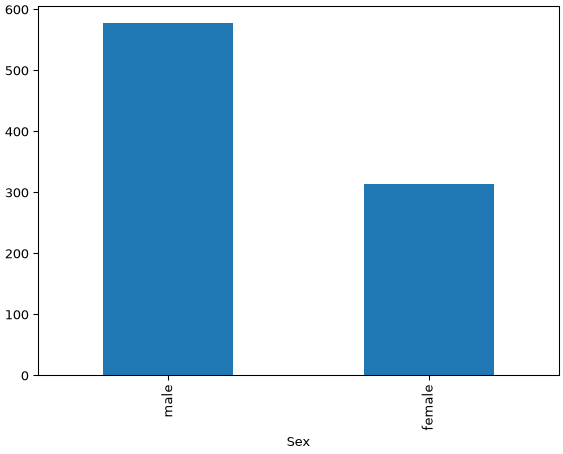

In [37]:
titanic['Sex'].value_counts().plot.bar()
plt.show()

We now consider the distribution of `Sex` among passengers less than
$18$ years old:

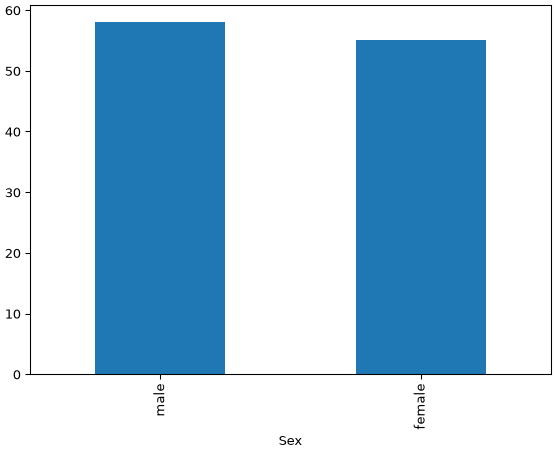

Sex
male      58
female    55
Name: count, dtype: int64

In [38]:
minor=titanic[titanic['Age']<18]
observed_frequencies = minor['Sex'].value_counts()
observed_frequencies.plot.bar()
plt.show()
observed_frequencies

This looks less biased, but there are still minor differences between
the counts. Are these due to chance? If `Sex` was distributed uniformly
(as we hypothesize), we would have the following frequencies:

In [39]:
expected_frequencies = [113/2, 113/2]
expected_frequencies

[56.5, 56.5]

We can run a Goodness-of-fit test to check if the observed frequencies
match the expected ones:

In [40]:
import seaborn as sns
import pandas as pd
from scipy.stats import chisquare

# Load the Titanic dataset
titanic_data = sns.load_dataset("titanic")

observed_frequencies = minor['Sex'].value_counts().values

# Define expected frequencies that closely match the observed data
expected_frequencies = [113/2, 113/2]

chi2, p_value = chisquare(f_obs=observed_frequencies, f_exp=expected_frequencies)

# Set the significance level (alpha)
alpha = 0.05

# Print the results
print("Observed Frequencies:")
print(observed_frequencies)
print("\nExpected Frequencies:")
print(expected_frequencies)
print("\nChi-Square Statistic:", chi2)
print("p-value:", p_value)

# Interpret the results
if p_value < alpha:
    print("\nThe observed data significantly deviates from the expected distribution.")
else:
    print("\nThe observed data fits the expected distribution.")

Observed Frequencies:
[58 55]

Expected Frequencies:
[56.5, 56.5]

Chi-Square Statistic: 0.07964601769911504
p-value: 0.7777776907897473

The observed data fits the expected distribution.

Given the large p-value, we could not reject the null hypothesis that
there are significant differences between expected and observed
frequencies.

#### Pearson/Spearman Correlation Test

We have seen how to compute Pearson/Spearman correlation coefficient.
However, what can we say when we get small values? Are those supposed to
be zero, but we got something different from zero due to sampling, or
are they significantly different from zero?

The statistical tests associated with the correlation coefficients are
used to determine whether the observed correlation between two variables
is statistically significant or if it might have occurred due to random
chance. This test assesses whether the correlation in the sample data is
likely to reflect a true correlation in the population.

The null hypothesis is that **there is no statistically significant
correlation between the two variables in the population**. In other
words, the true correlation coefficient in the population is zero.

Let us consider the Titanic dataset. We find the following correlation
between the `Age` and `Fare` variables:

Correlation between age and fare: 0.10

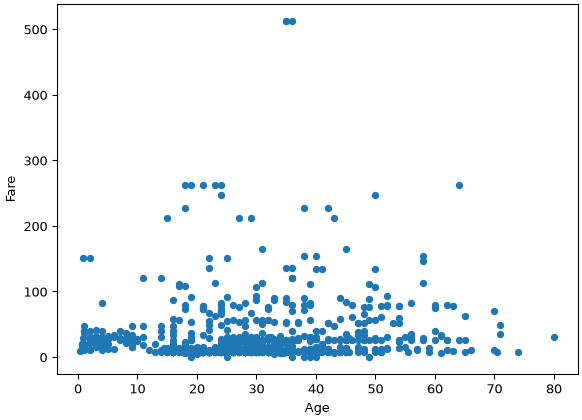

In [41]:
titanic.plot.scatter(x='Age',y='Fare')
tt=titanic.dropna()
print(f"Correlation between age and fare: {titanic[['Age','Fare']].dropna().corr().values[0][1]:.2f}")

Is this small positive correlation “true” or due to chance? Let us run a
statistical test:

In [42]:
import seaborn as sns
import pandas as pd
import scipy.stats as stats

tt = titanic[['Age','Fare']].dropna()

# Extract the 'age' and 'fare' columns
age = tt['Age']
fare = tt['Fare']

# Perform a Pearson correlation test
r, p_value = stats.pearsonr(age, fare)

# Define the significance level
alpha = 0.05

# Display the results
print(f"Pearson correlation coefficient (r): {r}")
print(f"P-value: {p_value}")

# Compare the p-value to alpha
if p_value <= alpha:
    print("Reject the null hypothesis. There is a significant correlation between age and fare.")
else:
    print("Fail to reject the null hypothesis. There is no significant correlation between age and fare.")

Pearson correlation coefficient (r): 0.0960666917690389
P-value: 0.010216277504447095
Reject the null hypothesis. There is a significant correlation between age and fare.

The p-value is small enough to reject the null hypothesis: the
correlation is small but statistically significant.

Similar tests exist for Spearman coefficient:

In [43]:
import seaborn as sns
import pandas as pd
import scipy.stats as stats

tt = titanic[['Age','Fare']].dropna()

# Extract the 'age' and 'fare' columns
age = tt['Age']
fare = tt['Fare']

# Perform a Pearson correlation test
r, p_value = stats.spearmanr(age, fare)

# Define the significance level
alpha = 0.05

# Display the results
print(f"Spearman correlation coefficient (r): {r}")
print(f"P-value: {p_value}")

# Compare the p-value to alpha
if p_value <= alpha:
    print("Reject the null hypothesis. There is a significant correlation between age and fare.")
else:
    print("Fail to reject the null hypothesis. There is no significant correlation between age and fare.")

Spearman correlation coefficient (r): 0.1350512177342878
P-value: 0.00029580903243060916
Reject the null hypothesis. There is a significant correlation between age and fare.

## Assessing whether a Sample is Normally Distributed

While the Normal distribution is pervasive, in some cases, it is useful
to assess whether a given sample follows a normal distribution before
assuming this is true. Let us consider the dataset of heights and
weights and plot the distribution of weights:

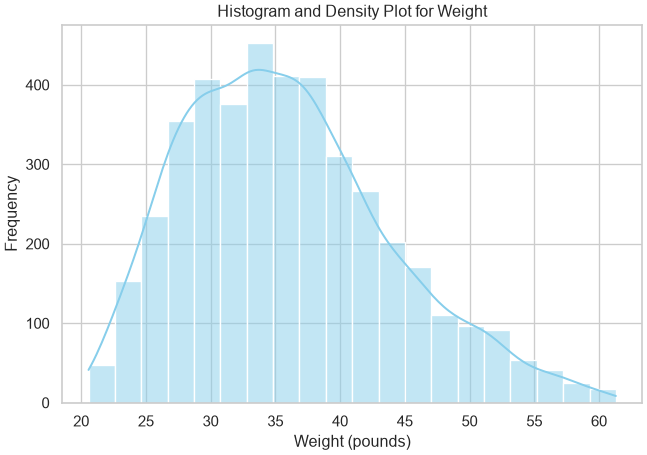

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
hw = pd.read_csv(DATA + "height_weight.csv")
hw['height'] = (hw['height'] / 2.54).astype(int)  # Convert height to inches
hw['weight'] = hw['weight'] / 2.205               # Convert weight to pounds

# Set up the plotting style
# `sns.set` rewrites the rcParams, including the transparent background the site
# uses (see site/notes/matplotlibrc), so it is asked to leave that alone. The
# whitegrid grid lines are grey, not white, so they survive the change.
sns.set(style="whitegrid",
        rc={"figure.facecolor": "none", "axes.facecolor": "none",
            "savefig.facecolor": "none"})

# Plotting for weight
sns.histplot(hw['weight'], kde=True, color="skyblue", bins=20)
plt.title('Histogram and Density Plot for Weight')
plt.xlabel('Weight (pounds)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Does the distribution look Gaussian? Let us compute Skewness and
Kurtosis:

In [45]:
import pandas as pd
from scipy.stats import skew, kurtosis

# Load and preprocess the data
hw = pd.read_csv(DATA + "height_weight_pounds.csv")

# Calculate skewness and kurtosis for weight
weight_skewness = skew(hw['weight'])
weight_kurtosis = kurtosis(hw['weight'])  

print(f"Skewness of weight: {weight_skewness:.2f}")
print(f"Kurtosis of weight: {weight_kurtosis:.2f}")

Skewness of weight: 0.57
Kurtosis of weight: -0.06

We not that: \* We have a positive Skewness: this indicates that the
distribution is skewed towards the right side (the right tail is longer)
as compared to a Normal distribution; \* We have a Kurtosis slightly
lower than zero: the distribution is slightly “flatter” than a Normal
distribution.

While Skewness and Kurtosis can help characterize deviations from
normality, there are tests which can be used.

### Quantile-Quantile Plots (Q-Q Plots)

Quantile-Quantile plots, or Q-Q plots, are a powerful tool to **assess
how well a sample matches a theoretical distribution**. The idea is
simple: we compare the **quantiles of the empirical data** with the
**quantiles of a reference distribution**—typically the normal
distribution.

To make the comparison meaningful and remove scale effects, the
empirical data is often **standardized into z-scores**. If the sample
truly follows the theoretical distribution, the quantiles will align,
and the points will fall along the diagonal line $y = x$.

Deviations from this line reveal **systematic differences** between the
empirical and theoretical distributions. For example: - A curve that
bends away from the diagonal suggests skewness. - S-shaped patterns may
indicate heavier or lighter tails than expected.

In the following graph, we show the Q-Q plot for the sample of cookie
package weights. It helps us visually evaluate whether the sample
distribution is approximately normal—a key assumption in many
statistical methods.

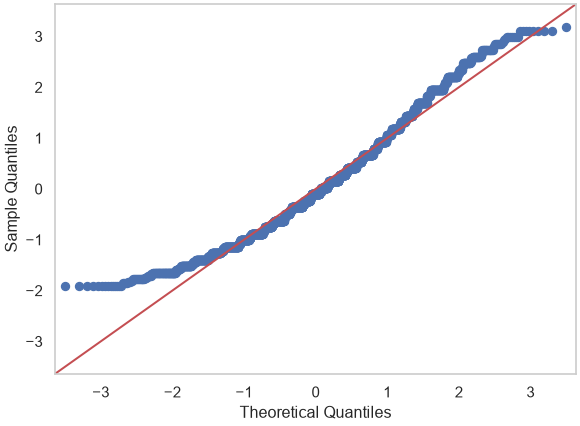

In [46]:
from statsmodels.graphics.gofplots import qqplot
import pandas as pd
from matplotlib import pyplot as plt

# fit=True means the distribution should be fitted to the data
# and the data should be standardized
# line='45' means a 45-degree reference line will be plotted
qqplot(hw['weight'], fit=True, line='45')
plt.grid()
plt.show()

The plot relates the “theoretical” quantiles with those of the sample.
The fact that the points on the plot do not lie on the diagonal
indicates that there is a discrepancy between the empirical data
distribution and the Gaussian distribution.

Analyzing a Q-Q Plot can be complex. In practice, **there are some
guidelines to understand how a sample deviates from a theoretical
distribution**. The following figure compares the q-q plots of different
distributions:

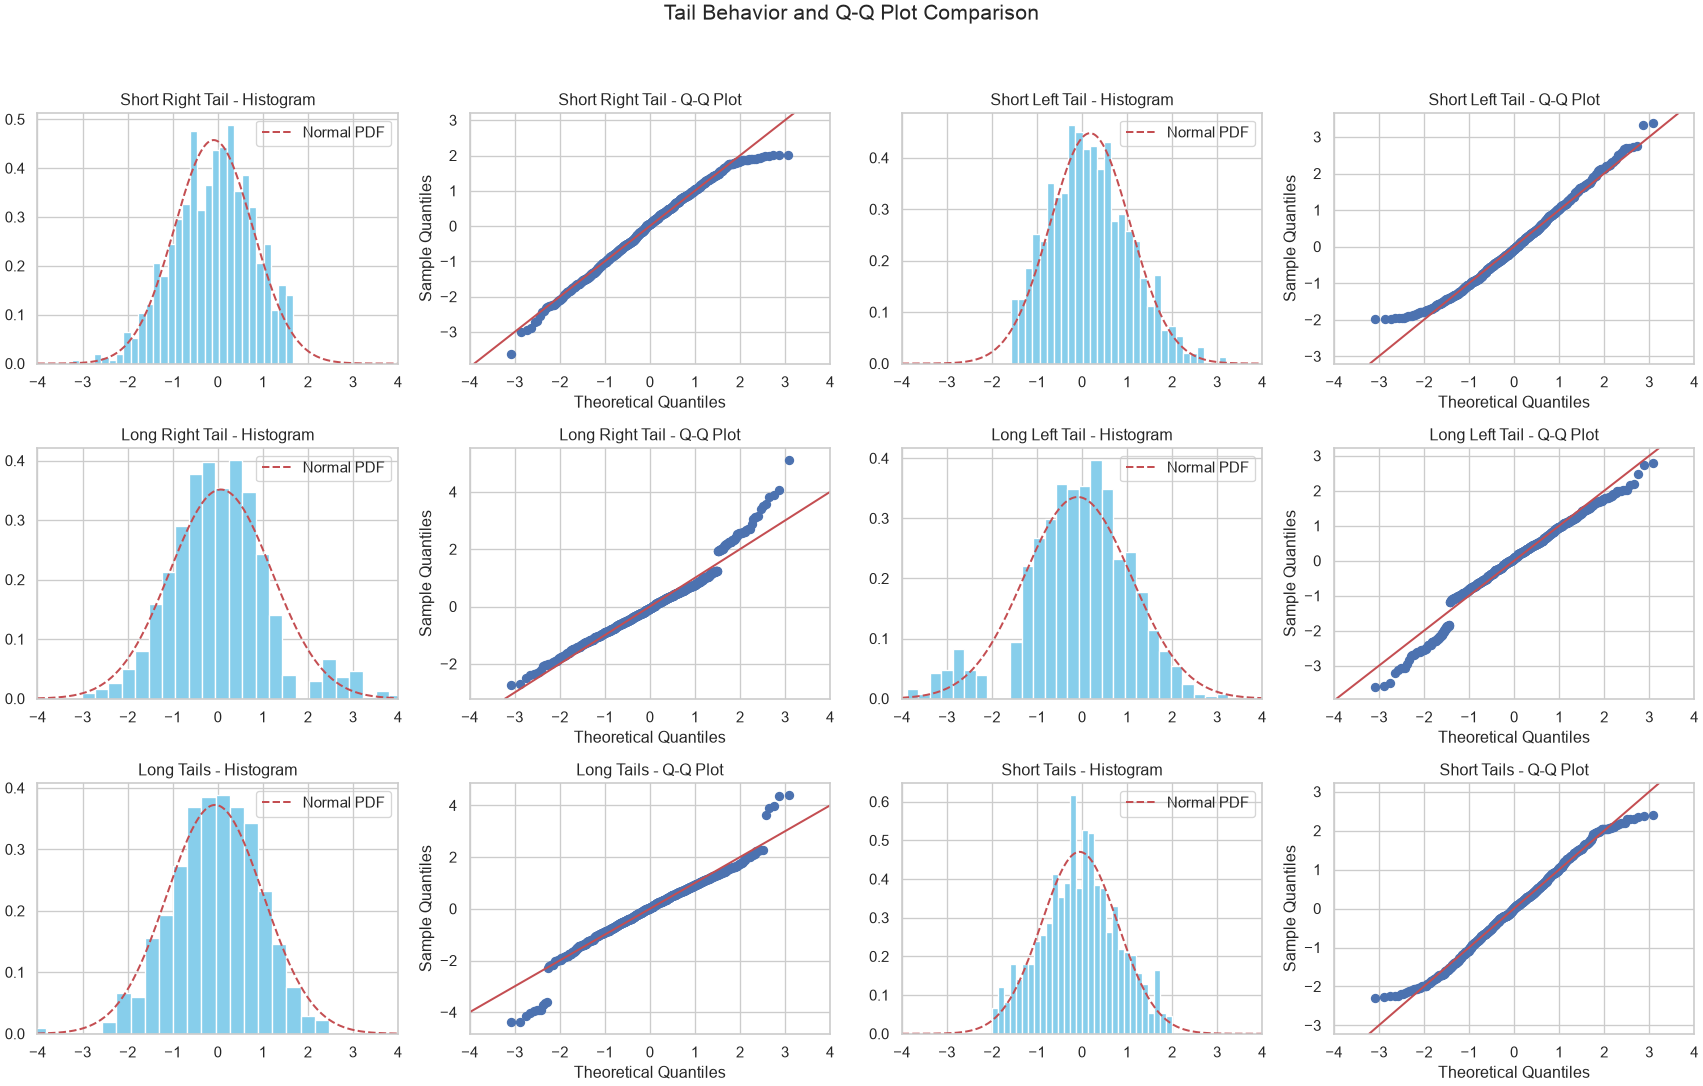

Every time we observe a Q-Q Plot, we can relate these features to
characteristics of the distribution. Clearly, these characteristics can
also combine to create more complex Q-Q Plots, as seen in the case of
weights.

### Shapiro-Wilk Normality Test

The Shapiro-Wilk test is a statistical test used to assess whether a
sample follows a Gaussian (normal) distribution. It is used with small
samples ($n\leq 2000$) It works by comparing the observed data to what
you would expect if the data were drawn from a truly Gaussian
distribution.

The null hypothesis for this test is that the population is normally
distributed.

We will not see the formal details of this test, but we can use it in
our analyses. Here is the result on the `weight` sample in our
height-weight dataset:

In [48]:
from scipy.stats import shapiro
import pandas as pd

# Perform the Shapiro-Wilk test
statistic, p_value = shapiro(hw['weight'])

# Set the significance level (alpha)
alpha = 0.05

print(f"Test statistic: {statistic:0.2f}")
print(f"P-value: {p_value:0.2f}")

# Check the p-value against the significance level
if p_value > alpha:
    print("Sample looks Gaussian (fail to reject H0)")
else:
    print("Sample does not look Gaussian (reject H0)")

Test statistic: 0.97
P-value: 0.00
Sample does not look Gaussian (reject H0)

### D’Agostino’s K-squared test

When samples are large ($n \geq 50$), the D’Agostino’s K-squared test is
more used. It is based on Skewness and Kurtosis.

The null hypothesis for this test is that the population is normally
distributed.

Here is the result for our example:

In [49]:
import pandas as pd
from scipy.stats import normaltest

# Perform D'Agostino's K-squared test
statistic, p_value = normaltest(hw['weight'])

# Set the significance level (alpha)
alpha = 0.05

print(f"Test statistic: {statistic:.2f}")
print(f"P-value: {p_value:.2f}")

# Check the p-value against the significance level
if p_value > alpha:
    print("Sample looks Gaussian (fail to reject H0)")
else:
    print("Sample does not look Gaussian (reject H0)")

Test statistic: 201.64
P-value: 0.00
Sample does not look Gaussian (reject H0)

## Exercises

> Exercise 1
>
> Consider the sample of all passengers in the titanic dataset. Compute
> the mean age of all passengers. Then, compute the confidence bounds
> for this mean setting the confidence level to 0.95. Is the estimated
> mean a reliable estimate of the population mean?

> Exercise 2
>
> Consider the samples of all passengers in the titanic dataset. Compute
> the variance of the ages of all passengers. Then, compute the
> confidence bounds for this variance setting the confidence level to
> 0.95. Is the estimated variance a reliable estimate of the population
> variance?

> Exercise 3
>
> Extract the sample of values of Sex of passengers in second class in
> the titanic dataset. Compute the contingency table of absolute counts
> of the Sex column. Compute the confidence bounds for the proportions
> of Sex in the sample. Are the estimated bounds reliable? Repeat the
> analysis for class 1 and 3.

> Exercise 4
>
> The average age of women in the US population is 40. Run a statistical
> test to assess whether the sample of ages in the `infert` dataset has
> the same mean as the US population. What is the result of the test?
> Are women in `infert` younger or older than the average?
>
> You can load the dataset installing the `pydataset` library with
> `pip install pydataset` and then:
>
> `from pydataset import data; infert = data("infert")`

> Exercise 5
>
> Consider the `titanic` dataset. Follow these steps to assess that
> males and females **are not equally distributed**:
>
> -   Obtain a table of absolute frequencies of the values of `Sex`;
> -   Show a barplot comparing the proportions of male and female
>     passengers. Do these look equally distributed?
> -   Run a statistical test to assess whether the proportion of males
>     and females are equal ($p=0.5$). What is the result of the test?
> -   Run the statistical test setting $p=1/3$. Is the result different?
>     Can we reject the null hypothesis? Why?

## References

-   Chapters 6-8 of \[1\];
-   Parts of chapter 9 of \[2\].

\[1\] Gonick, L., & Smith, W. (1993). The cartoon guide to statistics.
HarperCollins Publishers, Inc.

\[2\] Heumann, Christian, and Michael Schomaker Shalabh. Introduction to
statistics and data analysis. Springer International Publishing
Switzerland, 2016.